In [149]:
import os
import json

import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from openai import OpenAI
from pygments import highlight
from pygments.lexers import JsonLexer
from pygments.formatters import HtmlFormatter
from IPython.display import HTML, Markdown, display


In [96]:
df = pd.read_csv('../data/project_data.csv')
df.head()

,Project,Status,Budget,ActualCost,DelayDays,RiskLevel
0,Apollo,Complete,100000,120000,15,High
1,Mercury,In Progress,80000,75000,2,Low
2,Gemini,Delayed,150000,180000,30,High
3,Orion,Complete,50000,45000,0,Low
4,Phoenix,In Progress,120000,140000,10,Medium


In [ ]:
high_risk_records = high_risk_df.to_dict(orient="records")
print(high_risk_records)
print(type(high_risk_records))
print(type(high_risk_records[0]))

[{'Project': 'Apollo', 'Status': 'Complete', 'Budget': 100000, 'ActualCost': 120000, 'DelayDays': 15, 'RiskLevel': 'High', 'CostVariance': 20000, 'CostVariancePct': 20.0}, {'Project': 'Gemini', 'Status': 'Delayed', 'Budget': 150000, 'ActualCost': 180000, 'DelayDays': 30, 'RiskLevel': 'High', 'CostVariance': 30000, 'CostVariancePct': 20.0}, {'Project': 'Phoenix', 'Status': 'In Progress', 'Budget': 120000, 'ActualCost': 140000, 'DelayDays': 10, 'RiskLevel': 'Medium', 'CostVariance': 20000, 'CostVariancePct': 16.666666666666664}, {'Project': 'Atlas', 'Status': 'Delayed', 'Budget': 95000, 'ActualCost': 110000, 'DelayDays': 20, 'RiskLevel': 'High', 'CostVariance': 15000, 'CostVariancePct': 15.789473684210526}, {'Project': 'Titan', 'Status': 'In Progress', 'Budget': 200000, 'ActualCost': 230000, 'DelayDays': 25, 'RiskLevel': 'High', 'CostVariance': 30000, 'CostVariancePct': 15.0}, {'Project': 'Helios', 'Status': 'Delayed', 'Budget': 130000, 'ActualCost': 145000, 'DelayDays': 18, 'RiskLevel':

In [97]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Project     10 non-null     str  
 1   Status      10 non-null     str  
 2   Budget      10 non-null     int64
 3   ActualCost  10 non-null     int64
 4   DelayDays   10 non-null     int64
 5   RiskLevel   10 non-null     str  
dtypes: int64(3), str(3)
memory usage: 612.0 bytes


In [98]:
df.describe()

,Budget,ActualCost,DelayDays
count,10.000000,10.000000,10.000000
mean,105500.000000,117200.000000,12.100000
std,45853.026072,58520.271891,11.130039
min,50000.000000,45000.000000,0.000000
25%,72500.000000,69750.000000,1.250000
50%,97500.000000,115000.000000,12.500000
75%,127500.000000,143750.000000,19.500000
max,200000.000000,230000.000000,30.000000


In [99]:
df['CostVariance'] = df['ActualCost'] - df['Budget']
df['CostVariancePct'] = (df['CostVariance'] / df['Budget']) * 100

average_delay = df['DelayDays'].mean()
high_risk_count = (df['RiskLevel'] == 'High').sum()
average_cost_variance_pct = df['CostVariancePct'].mean()

print(f"Average Delay: {average_delay:.1f} days")
print(f"High Risk Projects: {high_risk_count}")
print(f"Average Cost Variance: {average_cost_variance_pct:.12}%")


Average Delay: 12.1 days
High Risk Projects: 4
Average Cost Variance: 7.82207923655%


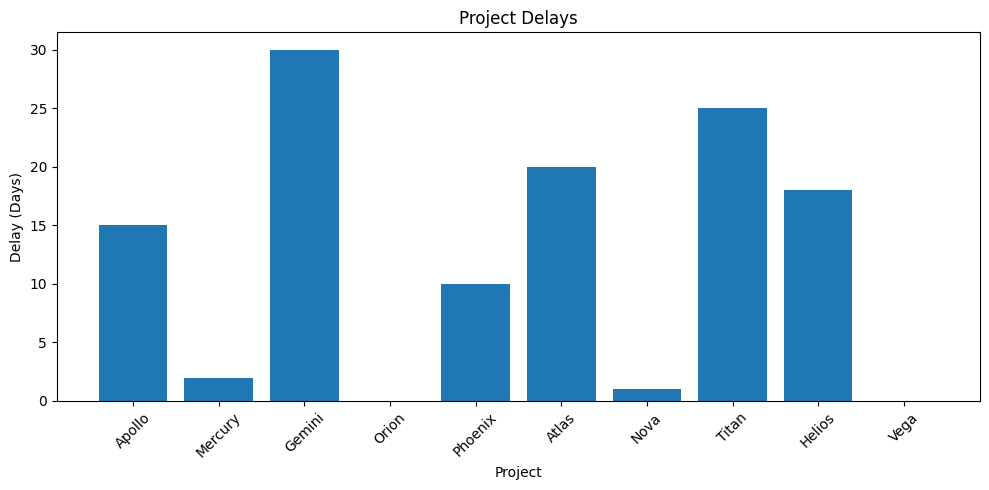

In [100]:
plt.figure(figsize=(10,5))
plt.bar(df["Project"], df["DelayDays"])
plt.xticks(rotation=45)
plt.title("Project Delays")
plt.xlabel("Project")
plt.ylabel("Delay (Days)")
plt.tight_layout()
plt.show()

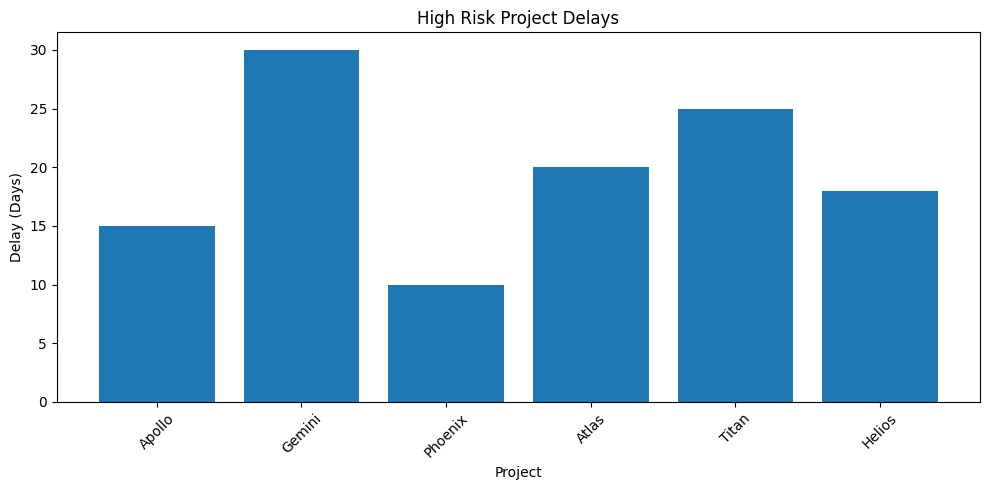

In [110]:
high_risk_df = df[
    (df["RiskLevel"] == "High")
    | (df["DelayDays"] > 10)
    | (df["CostVariancePct"] > 10)
]

plt.figure(figsize=(10,5))
plt.bar(high_risk_df["Project"], high_risk_df["DelayDays"])
plt.xticks(rotation=45)
plt.title("High Risk Project Delays")
plt.xlabel("Project")
plt.ylabel("Delay (Days)")
plt.tight_layout()
plt.show()

In [102]:
load_dotenv(override=True)
api_key = os.getenv("OPENAI_API_KEY")
print(api_key[:20])

sk-proj-rOdbEg8f0K5p


In [103]:
client = OpenAI(api_key=api_key)
print("Client created")


Client created


In [104]:
response = client.chat.completions.create(
    model="gpt-4.1-mini",
    messages=[
        {
            "role": "system",
            "content": (
                "You are an expert project delivery analyst."
            )
        },
        {
            "role": "user",
            "content": (
                "Summarise the risks of delayed "
                "and over-budget projects."
            )
        }
    ]
)

print(response.choices[0].message.content)


Delayed and over-budget projects pose several significant risks, including:

1. **Financial Impact**: Increased costs can strain budgets, reduce profitability, and potentially lead to funding shortfalls or financial losses.

2. **Reputation Damage**: Consistent delays and cost overruns can harm an organization’s credibility and stakeholder trust.

3. **Resource Strain**: Extended timelines consume more resources, potentially causing burnout, reduced productivity, and impacting other projects.

4. **Market Opportunity Loss**: Delays can result in missed market windows, allowing competitors to gain advantage or rendering the project’s output less relevant.

5. **Scope Creep and Quality Issues**: Budget and time pressures may lead to compromised quality or uncontrolled scope changes.

6. **Stakeholder Dissatisfaction**: Clients, investors, and other stakeholders may lose confidence, leading to strained relationships or contract disputes.

7. **Operational Disruptions**: Delays can disrupt

In [105]:
summary_prompt = f"""
You are an expert programme delivery analyst.

Here are the project metrics:

- Average delay days: {average_delay:.1f}
- High risk project count: {high_risk_count}
- Average cost variance percentage: {average_cost_variance_pct:.1f}%

Provide:
1. A short executive summary
2. Key delivery risks
3. Two recommended actions
"""

In [106]:
response = client.chat.completions.create(
    model="gpt-4.1-mini",
    messages=[
        {
            "role": "system",
            "content": "You are a senior delivery consultant."
        },
        {
            "role": "user",
            "content": summary_prompt
        }
    ]
)

print(response.choices[0].message.content)

1. Executive Summary:
The current programme metrics indicate schedule and cost challenges. An average delay of 12.1 days across projects points to consistent timeline slippage, while an average cost variance of 7.8% highlights budget overruns. The presence of four high-risk projects further underscores potential delivery volatility and impact on overall programme success.

2. Key Delivery Risks:
- Schedule overruns causing cascading delays in dependent activities.
- Budget overruns leading to reduced financial flexibility and potential funding shortfalls.
- High-risk projects increasing the probability of scope creep, quality issues, or stakeholder dissatisfaction.

3. Recommended Actions:
- Implement a rigorous risk mitigation and monitoring framework focused on high-risk projects to proactively identify and address issues before escalation.
- Enhance resource and schedule management through increased use of predictive analytics and contingency planning to reduce delays and control co

In [132]:
def pretty(obj):
    print(type(obj))

    if isinstance(obj, str):

        print(obj)

    else:

        formatted_json = json.dumps(
            obj,
            indent=2
        )

        formatter = HtmlFormatter(
            style="monokai"
        )

        html = (
            "<style>"
            + formatter.get_style_defs(".highlight")
            + "</style>"
            + highlight(
                formatted_json,
                JsonLexer(),
                formatter
            )
        )

        display(HTML(html))

In [108]:
pretty(response.model_dump())

In [134]:
high_risk_records = high_risk_df.to_dict(orient="records")
print(high_risk_records)
print(type(high_risk_records))
print(type(high_risk_records[0]))

[{'Project': 'Apollo', 'Status': 'Complete', 'Budget': 100000, 'ActualCost': 120000, 'DelayDays': 15, 'RiskLevel': 'High', 'CostVariance': 20000, 'CostVariancePct': 20.0}, {'Project': 'Gemini', 'Status': 'Delayed', 'Budget': 150000, 'ActualCost': 180000, 'DelayDays': 30, 'RiskLevel': 'High', 'CostVariance': 30000, 'CostVariancePct': 20.0}, {'Project': 'Phoenix', 'Status': 'In Progress', 'Budget': 120000, 'ActualCost': 140000, 'DelayDays': 10, 'RiskLevel': 'Medium', 'CostVariance': 20000, 'CostVariancePct': 16.666666666666664}, {'Project': 'Atlas', 'Status': 'Delayed', 'Budget': 95000, 'ActualCost': 110000, 'DelayDays': 20, 'RiskLevel': 'High', 'CostVariance': 15000, 'CostVariancePct': 15.789473684210526}, {'Project': 'Titan', 'Status': 'In Progress', 'Budget': 200000, 'ActualCost': 230000, 'DelayDays': 25, 'RiskLevel': 'High', 'CostVariance': 30000, 'CostVariancePct': 15.0}, {'Project': 'Helios', 'Status': 'Delayed', 'Budget': 130000, 'ActualCost': 145000, 'DelayDays': 18, 'RiskLevel':

In [154]:
project_prompt = f"""
You are a senior programme delivery consultant.

Analyse these high-risk software delivery projects:

{json.dumps(high_risk_records, indent=2)}

Return your response in markdown with these sections:

## Executive Summary

## Key Risks

## Root Causes

## Recommended Actions

Keep the tone concise and professional.
Only reference issues directly supported by the dataset.
Clearly distinguish observed facts from inferred risks.
"""

In [155]:
response = client.chat.completions.create(
    model="gpt-4.1-mini",
    messages=[
        {
            "role": "system",
            "content": (
                "You are a senior programme delivery consultant "
                "specialising in software delivery risk."
            )
        },
        {
            "role": "user",
            "content": project_prompt
        }
    ]
)

In [156]:
analysis = response.choices[0].message.content

display(Markdown(analysis))

## Executive Summary

Analysis of six projects with high or medium risk levels reveals consistent cost overruns and delivery delays, particularly among the high-risk projects. Three high-risk projects are delayed by 15 to 30 days and exceed budgets by 15% to 20%. The only completed project, Apollo, also finished late and over budget. Medium-risk projects show lower but still notable overruns and delays. These trends indicate systemic delivery challenges impacting cost and schedule adherence in this portfolio.

## Key Risks

- **Schedule Delays:** Among the high-risk projects, delays range from 15 to 30 days. Gemini and Atlas remain delayed, with delays of 30 and 20 days respectively.
- **Cost Overruns:** High-risk projects have cost variances between 15% and 20%, with Gemini and Apollo exceeding budgets by 20%.
- **Ongoing Cost Growth:** In-progress projects (Titan and Phoenix) are already over budget by 15% and 17%, with Titan also delayed by 25 days, suggesting continuing risk escalation.
- **Risk Level Correlation:** High-risk designation correlates strongly with both cost and schedule variances, reinforcing the validity of the risk assessment.

## Root Causes

- **Poor Cost Control:** Consistent cost variances across projects, including completed and in-progress ones, indicate inadequate budgeting or cost management.
- **Schedule Estimation Issues:** Delays of up to a month in delayed projects imply inaccurate initial schedule estimates or ineffective delay mitigation measures.
- **Risk Mitigation Gaps:** Persistence of high risk despite ongoing delivery suggests insufficient or ineffective risk response strategies.

## Recommended Actions

- **Rigorous Cost Monitoring:** Implement more frequent budget tracking with escalation triggers once variances approach 10%.
- **Schedule Reassessment and Contingency Planning:** Review schedule baselines and incorporate realistic buffer periods for high-risk projects to manage delay impact.
- **Risk Response Enhancement:** Develop targeted mitigation plans for high-risk projects focusing on identified cost and schedule drivers.
- **Post-Mortem Analysis:** Conduct detailed review of completed Apollo project to identify lessons learned for cost and delay control improvement.
- **Resource and Scope Review:** For in-progress projects showing overruns, reassess resource allocation and scope to identify opportunities to control further variance.

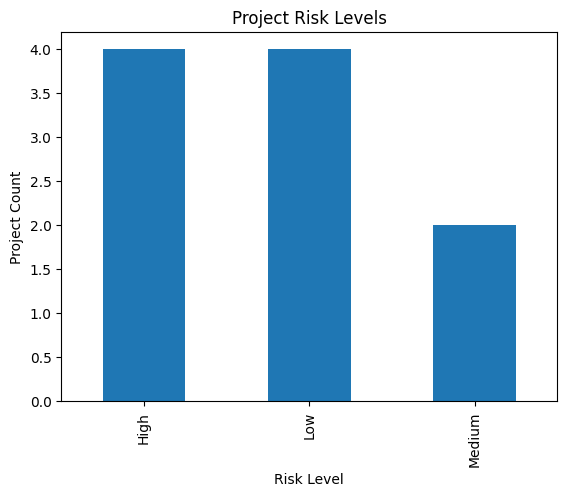

In [152]:
risk_counts = df["RiskLevel"].value_counts()
risk_counts.plot(kind="bar")

plt.title("Project Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Project Count")

plt.show()